# Semantic Repair Summary Plotter

This notebook compares `perfect_decompilation` outcomes and shows the normalized distribution of combined distances before and after semantic repair.

To reuse it on another run, set `SEMANTIC_REPAIR_RESULTS_CSV` or edit `csv_path` in the configuration cell.

In [1]:
from pathlib import Path
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")

# Default to the run that prompted this notebook. Override with an env var or by editing this path.
default_csv = Path("/home/diogenes/pylingual_colaboration/pylingual_download/code/results/experiment_outputs/20260429T051812Z/fe62855081c74a73a4c0008dc4674803/semantic_repair_results_pyllmpatch_dataset.csv")
csv_path = Path(os.getenv("SEMANTIC_REPAIR_RESULTS_CSV", str(default_csv))).expanduser().resolve()

if not csv_path.exists():
    raise FileNotFoundError(f"CSV not found: {csv_path}")

df = pd.read_csv(csv_path)
df["perfect_decompilation"] = df["perfect_decompilation"].astype("boolean")
df["initial_combined_distance"] = pd.to_numeric(df["initial_combined_distance"], errors="coerce")
df["final_combined_distance"] = pd.to_numeric(df["final_combined_distance"], errors="coerce")

summary = {
    "rows": len(df),
    "perfect_true": int((df["perfect_decompilation"] == True).sum()),
    "perfect_false": int((df["perfect_decompilation"] == False).sum()),
    "initial_total_distance": float(df["initial_combined_distance"].fillna(0).sum()),
    "final_total_distance": float(df["final_combined_distance"].fillna(0).sum()),
}
summary


{'rows': 20,
 'perfect_true': 15,
 'perfect_false': 3,
 'initial_total_distance': 943.0,
 'final_total_distance': 166.0}

/tmp/ipykernel_1808782/52211819.py:43: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, labels=labels, patch_artist=True, showfliers=False)


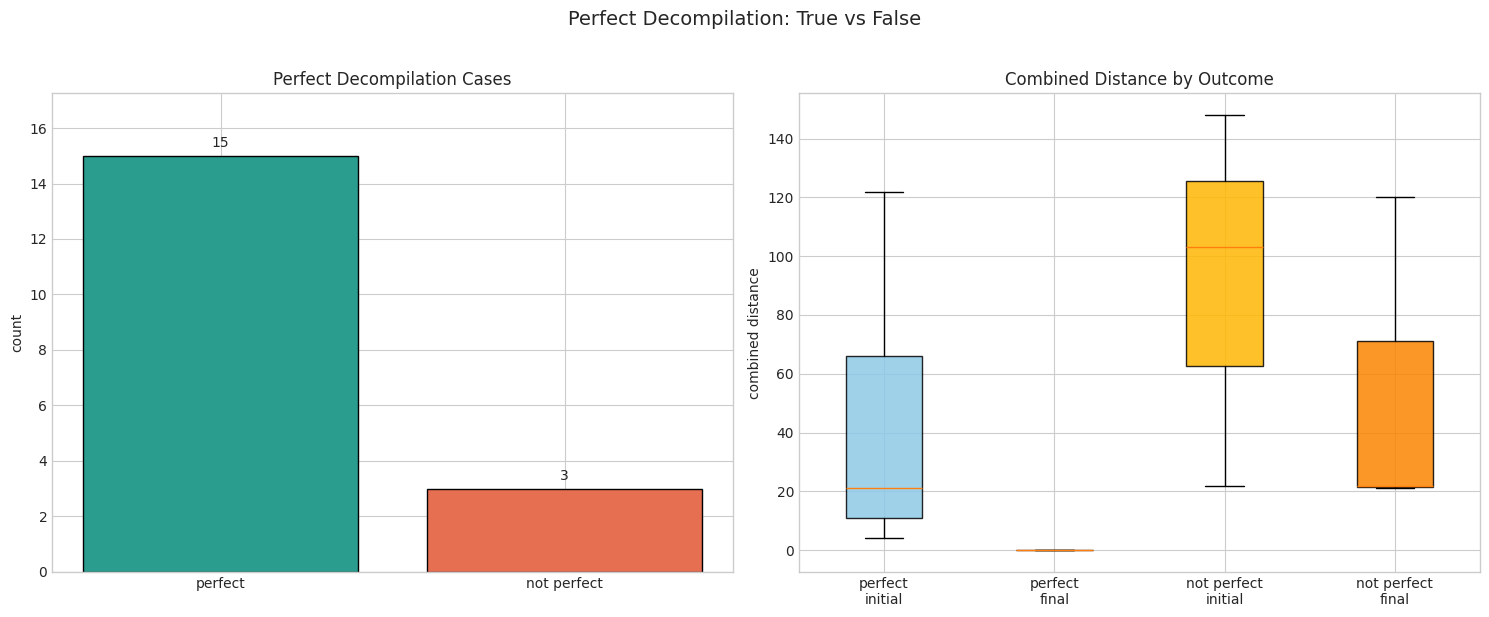

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left: count of perfect vs non-perfect cases.
ax = axes[0]
plot_counts = pd.Series(
    {
        "perfect": int((df["perfect_decompilation"] == True).sum()),
        "not perfect": int((df["perfect_decompilation"] == False).sum()),
    }
)
bars = ax.bar(plot_counts.index, plot_counts.values, color=["#2a9d8f", "#e76f51"], edgecolor="black", linewidth=1)
ax.set_title("Perfect Decompilation Cases")
ax.set_ylabel("count")
ax.set_ylim(0, max(plot_counts.values) * 1.15 if len(plot_counts) else 1)
for bar in bars:
    height = bar.get_height()
    ax.annotate(
        f"{int(height)}",
        (bar.get_x() + bar.get_width() / 2, height),
        ha="center",
        va="bottom",
        xytext=(0, 4),
        textcoords="offset points",
    )

perfect_true = df.loc[df["perfect_decompilation"] == True, ["initial_combined_distance", "final_combined_distance"]].copy()
perfect_false = df.loc[df["perfect_decompilation"] == False, ["initial_combined_distance", "final_combined_distance"]].copy()

# Right: compare the distance distributions for perfect vs non-perfect rows.
ax = axes[1]
box_data = [
    perfect_true["initial_combined_distance"].dropna(),
    perfect_true["final_combined_distance"].dropna(),
    perfect_false["initial_combined_distance"].dropna(),
    perfect_false["final_combined_distance"].dropna(),
]
labels = [
    "perfect\ninitial",
    "perfect\nfinal",
    "not perfect\ninitial",
    "not perfect\nfinal",
]
bp = ax.boxplot(box_data, labels=labels, patch_artist=True, showfliers=False)
palette = ["#8ecae6", "#219ebc", "#ffb703", "#fb8500"]
for patch, color in zip(bp["boxes"], palette):
    patch.set_facecolor(color)
    patch.set_alpha(0.85)
    patch.set_edgecolor("black")
ax.set_title("Combined Distance by Outcome")
ax.set_ylabel("combined distance")
ax.tick_params(axis="x", rotation=0)

fig.suptitle("Perfect Decompilation: True vs False", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()
